This notebook demonstrates how to load **panellinies_exams_dataset** from Hugging Face, inspect samples, and perform Exploratory Data Analysis (EDA) using specialized utility functions.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from datasets import load_dataset
from dotenv import load_dotenv, find_dotenv

sys.path.append(os.path.abspath('..'))

from src.eda_utils import (
    # --- Data Presentation ---
    display_samples,
    print_sample, 
    display_qa,
    
    # --- Multimodal (Images) ---
    get_image_samples_df,
    display_multimodal_samples, 
    
    # --- Distributions & Plots ---
    plot_subject_dist,      
    plot_school_type_dist,       
    plot_format_dist,       
    plot_reference_dist,    
    plot_temporal_distribution,
    plot_format_by_subject,      
    
    # --- Points Analysis ---
    plot_points_distribution,
    plot_points_by_school_type, 
    plot_points_by_subject,     
    
    # --- Source Tracking ---
    print_source_files
)

# Load environment variables
load_dotenv(find_dotenv())

repo_id = os.getenv("HF_REPO_ID")
token = os.getenv("HF_TOKEN")

print(f"Using Repository: {repo_id}")

c:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Repository: PennyK98/panellinies_exams_dataset


**1. Load the dataset**

In [3]:
dataset = load_dataset(repo_id, split="train", token=token, download_mode="force_redownload")
df = dataset.to_pandas()
#df = pd.read_excel("../results/panellinies_dataset.xlsx")

print(f"✅ Dataset loaded. Total rows: {len(df)}")

c:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\panag\.cache\huggingface\hub\datasets--PennyK98--panellinies_exams_dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|

✅ Dataset loaded. Total rows: 1318


In [23]:
# Μαθηματικά, Φυσική, Χημεία, Βιολογία, Πληροφορική
science_df = df[df['subject'].isin(['mathematics', 'physics', 'chemistry', 'biology', 'computer_science'])]
all_science_ids = science_df['id'].tolist()
random_id_sc = random.choice(all_science_ids)

# Νεοελληνική Γλώσσα, Αρχαία, Ιστορία, Λατινικά, ΑΟΘ
humanities_df = df[df['subject'].isin(['greek_language', 'ancient_greek', 'history', 'latin', 'economics'])]
all_humanities_ids = humanities_df['id'].tolist()
random_id_hum = random.choice(all_humanities_ids)

# --- Στοχευμένα IDs ---
target_id = 'chemistry_gel_2020_Δ3.i'
#chemistry_gel_2020_Δ3.i 
#chemistry_gel_2020_Δ3.ii
#chemistry_gel_2024_Δ2.α
#chemistry_gel_2024_Δ3.α
#chemistry_gel_2024_Δ2.β
#chemistry_gel_2024_B2.α
#physics_gel_2025_Δ3
#physics_gel_2021_B3.β
test_id = 'ancient_greek_gel_2025_Α1.α.1'

# --- Τυχαίο δείγμα Θετικών ---
#display_qa(df, random_id_sc)
display_qa(df, target_id)

#print_source_files(df, sample_id=random_id_sc)
print_source_files(df, sample_id=target_id)

# --- Συγκεκριμένο δείγμα ---
display_qa(df, test_id)
print_source_files(df, sample_id=test_id)

🔍 Identifying source files for ID: chemistry_gel_2020_Δ3.i
📂 Searching in: C:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\data
--------------------------------------------------


✅ **Source JSON:** [..\data\2020\GEL\ximeia\them_ximeia_gel_2020.json](..\data\2020\GEL\ximeia\them_ximeia_gel_2020.json)

✅ **Source MD:** &nbsp;&nbsp; [..\data\2020\GEL\ximeia\apant_ximeia_gel_2020.md](..\data\2020\GEL\ximeia\apant_ximeia_gel_2020.md)

--------------------------------------------------


🔍 Identifying source files for ID: ancient_greek_gel_2025_Α1.α.1
📂 Searching in: C:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\data
--------------------------------------------------


✅ **Source JSON:** [..\data\2025\GEL\arxaia\them_arxaia_gel_2025.json](..\data\2025\GEL\arxaia\them_arxaia_gel_2025.json)

✅ **Source MD:** &nbsp;&nbsp; [..\data\2025\GEL\arxaia\apant_arxaia_gel_2025.md](..\data\2025\GEL\arxaia\apant_arxaia_gel_2025.md)

--------------------------------------------------


**2. Main samples inspection**

**3. Multimodal Analysis**

id,subject,format,reference,question,input,image,choices,answer_text,answer_index,image_description,image_transcription,points,year,school_type
chemistry_gel_2022_Γ3.α,chemistry,open_ended,multimodal,Το παραγόμενο αέριο NO διοχετεύεται σε δοχείο που περιέχει $O_{2}$. Στους $25^{\circ}C$ και πίεση P=1 atm πραγματοποιείται η μονόδρομη αντίδραση $2NO(g) + O_{2}(g) \rightarrow 2NO_{2}(g)$ για την οποία δίνονται τα παρακάτω πειραματικά δεδομένα. Να γράψετε τον νόμο ταχύτητας της αντίδρασης.,,,,$v = k[\ce{NO}]^{2}[\ce{O2}]$. Προκύπτει συγκρίνοντας τα πειράματα $1-2$ (διπλασιασμός $[\ce{NO}]$ τετραπλασιάζει την ταχύτητα → τάξη $2$) και $1-3$ (διπλασιασμός $[\ce{O2}]$ διπλασιάζει την ταχύτητα → τάξη $1$).,,"Figure 2: A table presenting experimental data for a chemical reaction. The columns are labeled πείραμα, [NO]αρχ / mol·L⁻¹, [O₂]αρχ / mol·L⁻¹, and uαρχ / mol·L⁻¹·s⁻¹. Three experiments are listed. In experiment 1, the initial concentration of NO is 2 · 10⁻² mol·L⁻¹, the initial concentration of O₂ is 5 · 10⁻³ mol·L⁻¹, and the initial reaction rate is 3,2 · 10⁻³ mol·L⁻¹·s⁻¹. In experiment 2, the initial concentration of NO is 4 · 10⁻² mol·L⁻¹, the initial concentration of O₂ remains 5 · 10⁻³ mol·L⁻¹, and the initial reaction rate is 12,8 · 10⁻³ mol·L⁻¹·s⁻¹. In experiment 3, the initial concentration of NO is 2 · 10⁻² mol·L⁻¹, the initial concentration of O₂ is 2,5 · 10⁻³ mol·L⁻¹, and the initial reaction rate is 1,6 · 10⁻³ mol·L⁻¹·s⁻¹.","πείραμα, [NO]αρχ / mol·L⁻¹, [O₂]αρχ / mol·L⁻¹, uαρχ / mol·L⁻¹·s⁻¹, 1, 2 · 10⁻², 5 · 10⁻³, 3,2 · 10⁻³, 2, 4 · 10⁻², 5 · 10⁻³, 12,8 · 10⁻³, 3, 2 · 10⁻², 2,5 · 10⁻³, 1,6 · 10⁻³",5.0,2022,GEL
biology_gel_2020_Δ4.ii,biology,open_ended,multimodal,"Επιθυμούμε να κλωνοποιήσουμε το γονίδιο Α, χρησιμοποιώντας ως φορέα κλωνοποίησης το πλασμίδιο του Σχήματος 1. Διαθέτουμε τρεις διαφορετικές περιοριστικές ενδονουκλεάσες τις Ι, ΙΙ και EcoRI. Το πλασμίδιο φέρει γονίδιο ανθεκτικότητας στην αμπικιλίνη, γονίδιο ανθεκτικότητας στην στρεπτομυκίνη και δύο θέσεις αναγνώρισης από τις περιοριστικές ενδονουκλεάσες ΠΕ-Ι και ΠΕ-ΙΙ. Η περιοριστική ενδονουκλεάση I διαθέτει θέση αναγνώρισης μέσα στο γονίδιο ανθεκτικότητας της αμπικιλίνης, ενώ η περιοριστική ενδονουκλεάση ΙΙ διαθέτει θέση αναγνώρισης μέσα στο γονίδιο της στρεπτομυκίνης. Δίνονται οι αλληλουχίες έξι ζευγών βάσεων που αναγνωρίζουν και επιδρούν οι ΠΕ-Ι και ΠΕ-ΙΙ. Tα βέλη υποδεικνύουν τη θέση που δρα η κάθε περιοριστική ενδονουκλεάση (ΠΕ) στην αλληλουχία αναγνώρισης.Ποια/ποιες είναι η/οι αλληλουχία/ες έξι ζευγών βάσεων που εμφανίζεται/εμφανίζονται εκατέρωθεν του τμήματος του γονιδίου, στην περιοχή σύνδεσης των μονόκλωνων άκρων μετά την ενσωμάτωσή του στο πλασμίδιο με τη δράση της DNA δεσμάσης;",,,,Η αλληλουχία που εμφανίζεται εκατέρωθεν είναι: $5'$-GAATTC-$3'$ και $3'$-CTTAAG-$5'$.,,"Figure 4: A circular diagram representing a plasmid containing two antibiotic resistance genes. Inside the plasmid, two regions are labeled: «Γονίδιο ανθεκτικότητας στην αμπικιλίνη» and «Γονίδιο ανθεκτικότητας στη στρεπτομυκίνη». Two specific sites on the plasmid are indicated on the outer ring with arrows labeled I and II, marking distinct positions on the DNA molecule. The diagram illustrates the location of resistance genes and specific sites within the plasmid. | Figure 5: A diagram showing two restriction enzyme recognition sites labeled ΠΕ-I and ΠΕ-II.","Γονίδιο ανθεκτικότητας στην αμπικιλίνη, Γονίδιο ανθεκτικότητας στη στρεπτομυκίνη, I, II",4.0,2020,GEL
physics_gel_2025_B2.α,physics,multiple_choice,multimodal,"Εγκάρσιο κύμα διαδίδεται σε νήμα κατά τη διεύθυνση του άξονα $x'x$ του Σχήματος 1. Τα διαδοχικά σημεία Κ, Λ, Μ, Ν απέχουν από τα γειτονικά τους απόσταση $\lambda/4$. Τη χρονική στιγμή $t_1$, που το κύμα έχει ήδη διαδοθεί στην περιοχή ΚΝ, το σημείο Μ βρίσκεται στη θέση ισορροπίας και η ταχύτητά του $\vec{\upsilon}_M$ είναι αρνητική, έχοντας φάση $\varphi_M < \varphi_\Lambda$. Τη χρονική στιγμή $t_1 + 3T/2$ το στιγμιότυπο του κύματος στην περιοχή ΚΝ σε ποια από τις παρακάτω απε
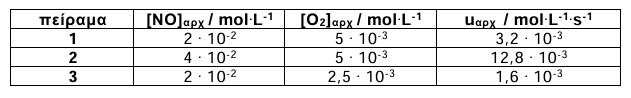
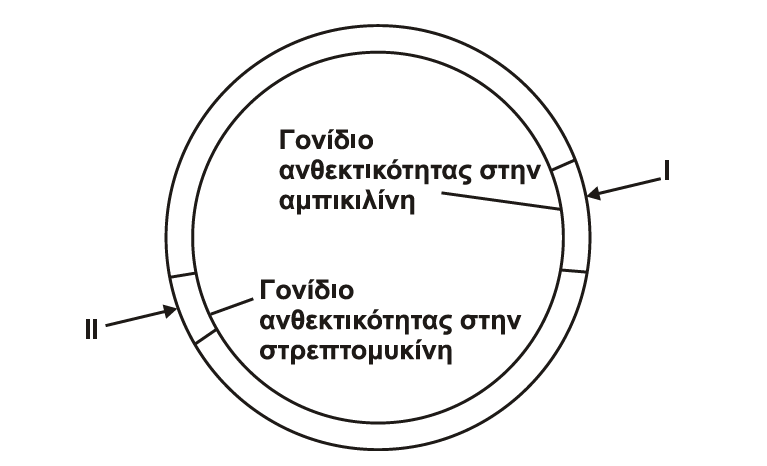
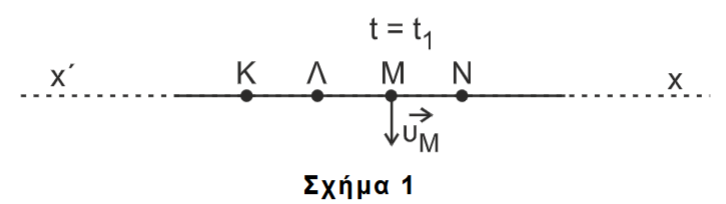

In [21]:
display_samples(df, n=3, prioritize_images=True)

4.1 Distribution by Subject and School Type

,Subject,Count
0,ancient_greek,192
1,latin,177
2,chemistry,175
3,physics,147
4,biology,140
5,mathematics,126
6,economics,115
7,computer_science,90
8,history,84
9,greek_language,72


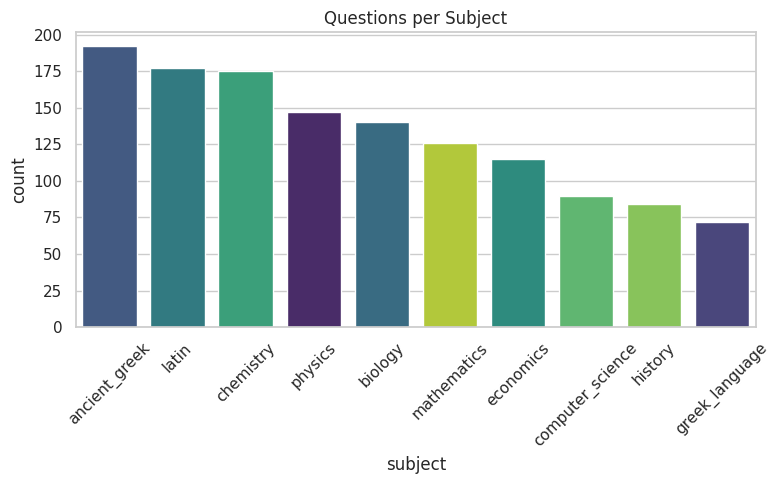

In [6]:
# Subject Distribution
fig_subj, df_subj = plot_subject_dist(df)
display(df_subj)
display(fig_subj)

,School Type,Count
0,GEL,1318


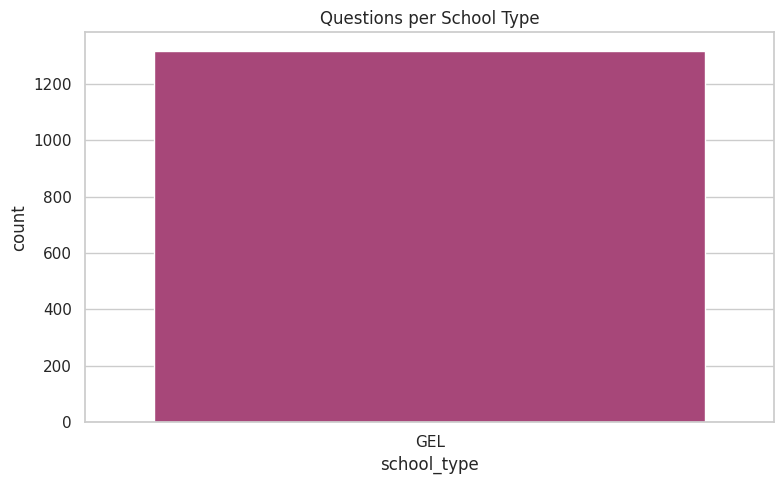

In [7]:
# School Type Distribution
fig_school, df_school = plot_school_type_dist(df)
display(df_school)
display(fig_school)

4.2 Distribution by Format and Reference Type

,Format,Count
0,open_ended,886
1,true_false,228
2,multiple_choice,158
3,fill_in_the_gaps,32
4,matching,14


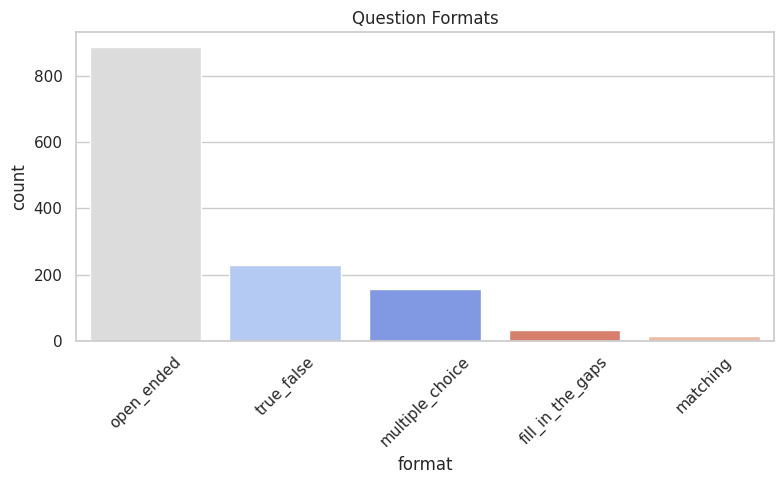

In [8]:
# Question Format Distribution
fig_format, df_format = plot_format_dist(df)
display(df_format)
display(fig_format)

,Reference,Count
0,none,897
1,passage,214
2,multimodal,206
3,table,1


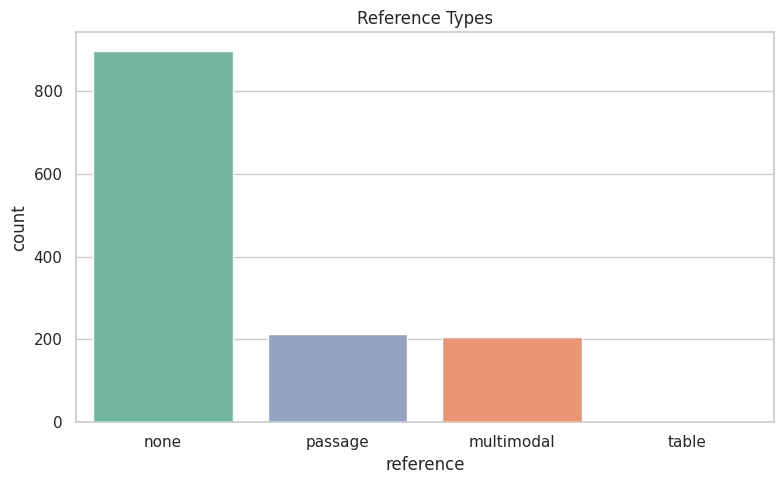

In [9]:
# Reference Type Distribution
fig_ref, df_ref = plot_reference_dist(df)
display(df_ref)
display(fig_ref)

4.3 Temporal Trends

subject,ancient_greek,biology,chemistry,computer_science,economics,greek_language,history,latin,mathematics,physics
year,,,,,,,,,,
2020,33.0,22.0,34.0,16.0,17.0,16.0,14.0,40.0,21.0,24.0
2021,28.0,18.0,25.0,15.0,21.0,11.0,15.0,0.0,22.0,24.0
2022,22.0,22.0,23.0,15.0,20.0,11.0,14.0,33.0,21.0,24.0
2023,35.0,29.0,31.0,14.0,20.0,11.0,14.0,30.0,20.0,26.0
2024,42.0,27.0,33.0,17.0,19.0,11.0,13.0,33.0,22.0,26.0
2025,32.0,22.0,29.0,13.0,18.0,12.0,14.0,41.0,20.0,23.0


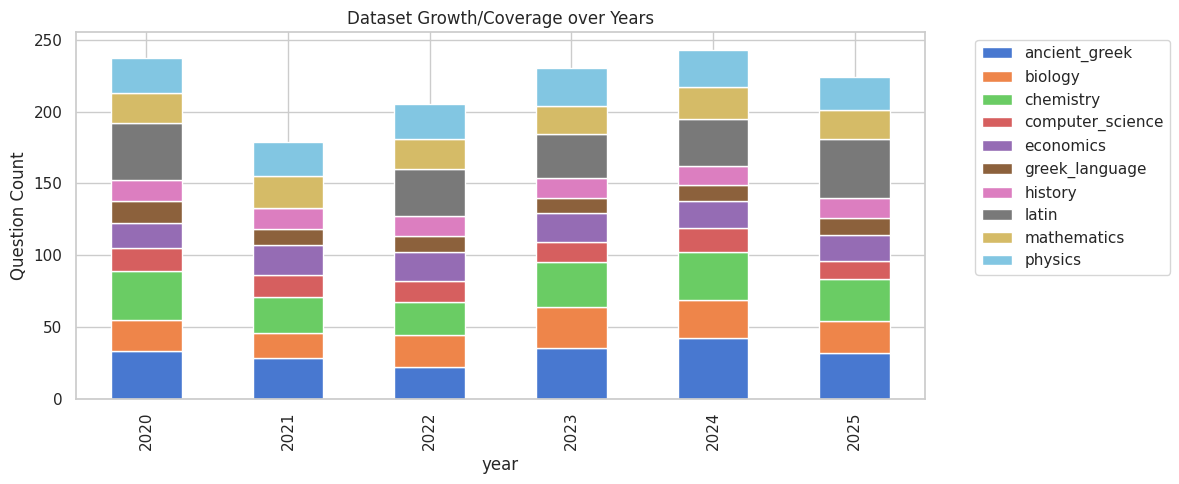

In [10]:
# Temporal Trends (Distribution over years per subject)
fig_temp, df_temp = plot_temporal_distribution(df)
display(df_temp)
display(fig_temp)

4.4 Point Values & Format Analysis

Percentage of questions with point values assigned:
100.00%


,count,mean,std,min,25%,50%,75%,max
points,1318.0,4.526176,4.170834,1.0,2.0,3.0,6.0,30.0


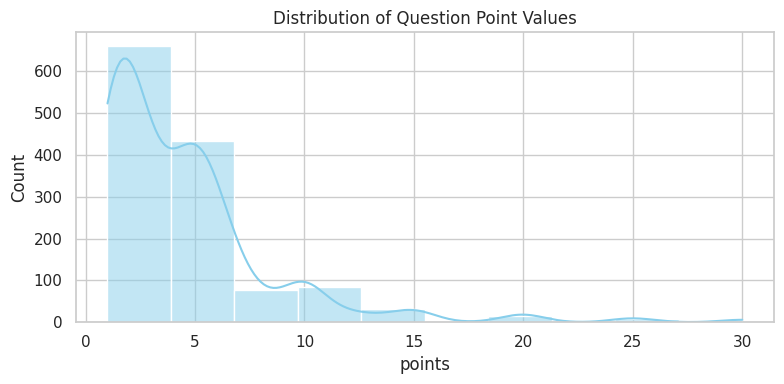

In [11]:
# Points Distribution
fig_points, df_points = plot_points_distribution(df)
display(df_points)
if fig_points is not None:
    display(fig_points)

,count,mean,std,min,25%,50%,75%,max
school_type,,,,,,,,
GEL,1318.0,4.526176,4.170834,1.0,2.0,3.0,6.0,30.0


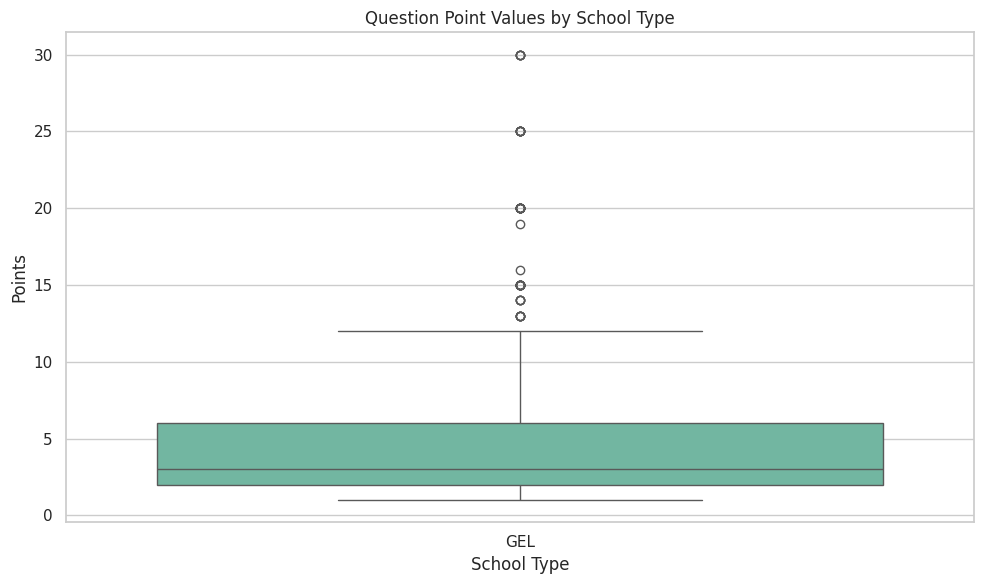

In [12]:
# Points by School Type 
fig_pts_school, df_pts_school = plot_points_by_school_type(df)
display(df_pts_school)
if fig_pts_school is not None:
    display(fig_pts_school)

,count,mean,std,min,25%,50%,75%,max
subject,,,,,,,,
ancient_greek,192.0,3.145833,3.645205,1.0,1.00,2.0,2.00,20.0
biology,140.0,4.400000,1.872943,1.0,3.00,5.0,5.00,10.0
chemistry,175.0,3.531429,1.932150,1.0,2.00,3.0,5.00,10.0
computer_science,90.0,6.655556,6.790875,2.0,2.00,4.5,7.75,25.0
economics,115.0,5.217391,3.316050,2.0,3.00,4.0,6.00,25.0
greek_language,72.0,8.541667,8.332758,1.0,2.00,3.5,15.00,30.0
history,84.0,6.988095,5.200774,2.0,2.00,5.0,12.00,25.0
latin,177.0,2.974576,3.616672,1.0,1.00,1.5,2.00,20.0
mathematics,126.0,4.761905,2.110653,1.0,2.25,5.0,6.00,10.0


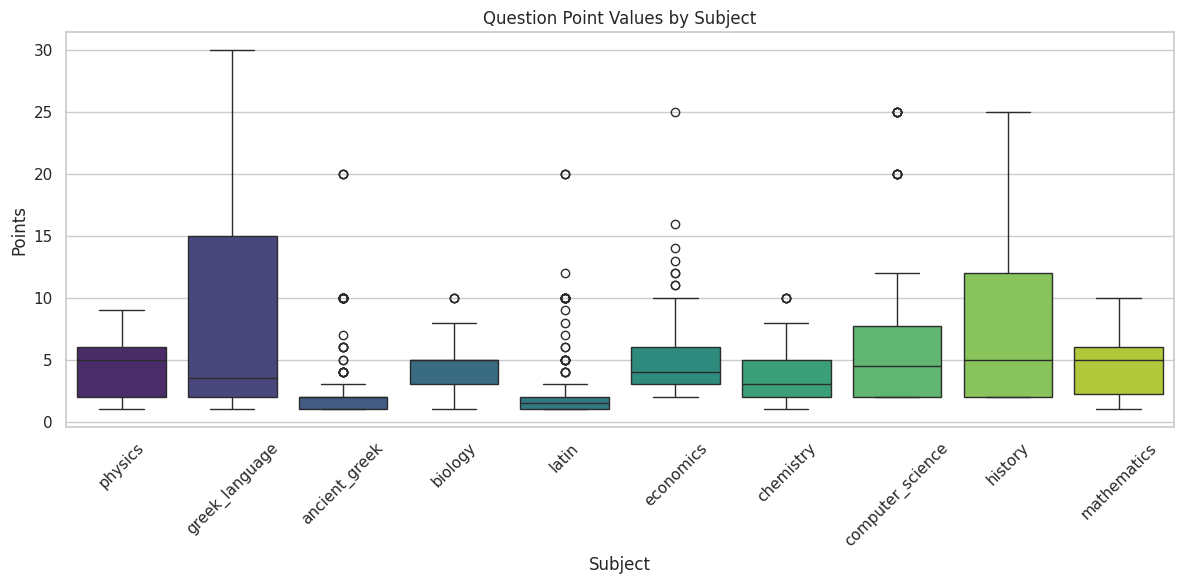

In [13]:
# Points by Subject
fig_pts_subj, df_pts_subj = plot_points_by_subject(df)
display(df_pts_subj)
if fig_pts_subj is not None:
    display(fig_pts_subj)

format,fill_in_the_gaps,matching,multiple_choice,open_ended,true_false
subject,,,,,
ancient_greek,10,6,18,131,27
biology,0,4,37,99,0
chemistry,0,0,32,123,20
computer_science,7,1,0,52,30
economics,5,0,12,68,30
greek_language,0,0,10,42,20
history,0,0,0,54,30
latin,10,3,5,149,10
mathematics,0,0,0,95,31


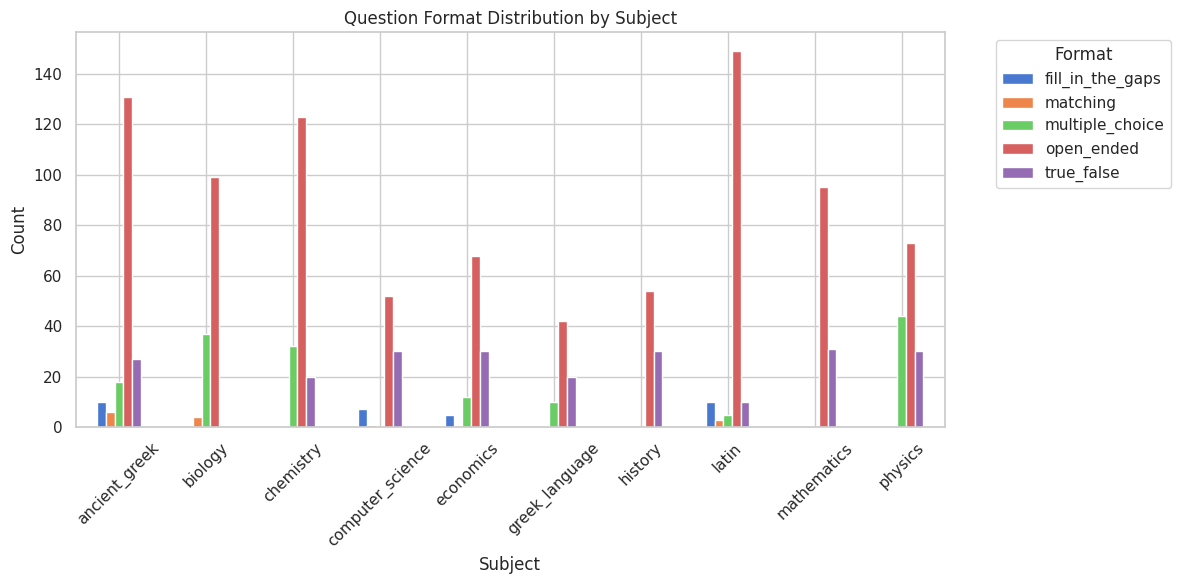

In [14]:
# Format by Subject
fig_fmt, df_fmt = plot_format_by_subject(df)
display(df_fmt)
display(fig_fmt)

4.5 Unique verification

In [15]:
# 1. Μετατρέπουμε προσωρινά τις λίστες (choices) σε tuples για να μπορούν να συγκριθούν
if 'choices' in df.columns:
    choices_hashable = df['choices'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
else:
    choices_hashable = None

# 2. Έλεγχος μοναδικότητας του 'id'
if 'id' in df.columns:
    is_id_unique = df['id'].is_unique
    print(f"Is 'id' column unique? {is_id_unique}")
    if not is_id_unique:
        num_duplicates = df.duplicated('id').sum()
        print(f"Number of duplicate IDs: {num_duplicates}")

# 3. Έλεγχος για ερωτήσεις με ολόιδιο περιεχόμενο (Question + Input)
subset_to_check = []
if 'question' in df.columns: subset_to_check.append('question')
if 'input' in df.columns: subset_to_check.append('input')

if subset_to_check:
    content_duplicates = df.duplicated(subset=subset_to_check).sum()
    print(f"Rows with identical content (Question/Input): {content_duplicates}")
    
    # Αν βρει διπλότυπα, τα τυπώνει για να τα δεις
    if content_duplicates > 0:
        print("\nDisplaying samples of content duplicates:")
        dup_rows = df[df.duplicated(subset=subset_to_check, keep=False)]
        display(dup_rows.sort_values(by='question')[['id', 'subject', 'year', 'question']])

# 4. Έλεγχος για κενές τιμές (nulls) σε κρίσιμες στήλες
critical_cols = ['id', 'subject', 'school_type', 'question', 'format']
existing_critical = [c for c in critical_cols if c in df.columns]
null_counts = df[existing_critical].isnull().sum()

if null_counts.sum() > 0:
    print("\n⚠️ Null values in critical columns:")
    print(null_counts[null_counts > 0])
else:
    print(f"\n✅ No null values in critical columns ({', '.join(existing_critical)}).")

Is 'id' column unique? True
Rows with identical content (Question/Input): 2

Displaying samples of content duplicates:


,id,subject,year,question
55,ancient_greek_gel_2020_B4.α,ancient_greek,2020,Να αντιστοιχίσετε στο τετράδιό σας καθεμιά αρχ...
1189,ancient_greek_gel_2021_B4.α,ancient_greek,2021,Να αντιστοιχίσετε στο τετράδιό σας καθεμιά αρχ...
867,chemistry_gel_2025_B1.α.1,chemistry,2025,Ποια δύο (2) από τα παρακάτω άτομα ή ιόντα είν...
868,chemistry_gel_2025_B1.α.2,chemistry,2025,Ποια δύο (2) από τα παρακάτω άτομα ή ιόντα είν...



✅ No null values in critical columns (id, subject, school_type, question, format).


In [16]:
# 1. Βρίσκει γραμμές που έχουν το κυριολεκτικό '\n' (ως κείμενο)
literal_nl_mask = df['answer_text'].str.contains(r'\\n', regex=True, na=False)
literal_nl_ids = df[literal_nl_mask]['id'].tolist()

# 2. Βρίσκει γραμμές που είναι λίστες μετατρεπόμενες σε strings π.χ. "['a', 'b']"
json_list_mask = df['answer_text'].str.startswith('[', na=False) & df['answer_text'].str.endswith(']', na=False)
json_list_ids = df[json_list_mask]['id'].tolist()

# 3. Βρίσκει τις "σωστές" απαντήσεις που έχουν πραγματικές αλλαγές γραμμής
true_multiline_mask = df['answer_text'].str.contains('\n', na=False)
true_multiline_ids = df[true_multiline_mask]['id'].tolist()

print(f"📊 Rows with literal '\\n': {len(literal_nl_ids)}")
if literal_nl_ids: print(f"IDs: {literal_nl_ids[:10]} ...\n")

print(f"📦 Rows with stringified lists: {len(json_list_ids)}")
if json_list_ids: print(f"IDs: {json_list_ids[:10]} ...\n")

print(f"✅ Rows already using real newlines: {len(true_multiline_ids)}")
if true_multiline_ids: print(f"IDs: {true_multiline_ids[:10]} ...")

📊 Rows with literal '\n': 43
IDs: ['physics_gel_2020_Δ1', 'physics_gel_2020_Δ3', 'physics_gel_2020_Δ4', 'mathematics_gel_2020_B2', 'mathematics_gel_2020_Γ1', 'mathematics_gel_2020_Γ2', 'mathematics_gel_2020_Γ3', 'mathematics_gel_2020_Δ1', 'physics_gel_2024_B1.β', 'physics_gel_2024_Γ3'] ...

📦 Rows with stringified lists: 13
IDs: ['ancient_greek_gel_2020_B4.α', 'computer_science_gel_2024_A2', 'ancient_greek_gel_2023_A1.β', 'biology_gel_2023_B1.α', 'biology_gel_2025_B1', 'latin_gel_2025_B2', 'ancient_greek_gel_2022_A1.β', 'ancient_greek_gel_2022_B3', 'ancient_greek_gel_2022_B4.α', 'biology_gel_2022_Β1'] ...

✅ Rows already using real newlines: 399
IDs: ['physics_gel_2020_B1.β', 'physics_gel_2020_B2.β', 'physics_gel_2020_B3.β', 'physics_gel_2020_Γ1', 'physics_gel_2020_Γ2', 'physics_gel_2020_Γ3', 'physics_gel_2020_Γ4', 'physics_gel_2020_Δ1', 'physics_gel_2020_Δ2', 'physics_gel_2020_Δ3'] ...


In [17]:
from IPython.display import Markdown

# Φορτώνουμε το dataset απευθείας από το Hugging Face
dataset = load_dataset(repo_id, split="train", token=token)

# Διάλεξε ένα δικό σου ID για τεστ
target_id = "ancient_greek_gel_2025_Α1.α.1" 

subset = dataset.filter(lambda x: x["id"] == target_id)

if len(subset) > 0:
    sample = subset[0]
    
    md_output = f"### ID: {sample['id']}\n"
    md_output += f"**Question:** {sample['question']}\n\n"
    
    if sample.get('input'):
        md_output += f"**Input:**\n{sample['input']}\n\n"
        
    if sample.get('images'):
        md_output += f"🖼️ **Images Attached:** {len(sample['images'])}\n\n"
        
    if sample.get('choices'):
        md_output += "#### Choices:\n"
        correct_idx = sample.get('answer_index')
        for i, choice in enumerate(sample['choices']):
            marker = "✅" if i == correct_idx else "⬜"
            md_output += f"- [{marker}] **{i}**: {choice}\n"
        md_output += f"\n**Correct Answer Index:** `{correct_idx}`"
    else:
        md_output += f"\n**Answer:**\n{sample['answer_text']}"
        
    display(Markdown(md_output))
else:
    print(f"ID {target_id} not found in Hugging Face dataset.")

Filter:   0%|          | 0/1318 [00:00<?, ? examples/s]

### ID: ancient_greek_gel_2025_Α1.α.1
**Question:** Ποια είναι η κύρια αιτία η οποία εμποδίζει τους δεσμώτες να στρέψουν τα κεφάλια τους;

**Input:**
Πλάτωνος Πολιτεία (514a-515c)

Μετὰ ταῦτα δή, εἶπον, ἀπείκασον τοιούτῳ πάθει τὴν ἡμετέραν φύσιν παιδείας τε πέρι καὶ ἀπαιδευσίας. Ἰδὲ γὰρ ἀνθρώπους οἷον ἐν καταγείῳ οἰκήσει σπηλαιώδει, ἀναπεπταμένην πρὸς τὸ φῶς τὴν εἴσοδον ἐχούσῃ μακρὰν παρὰ πᾶν τὸ σπήλαιον, ἐν ταύτῃ ἐκ παίδων ὄντας ἐν δεσμοῖς καὶ τὰ σκέλη καὶ τοὺς αὐχένας, ὥστε μένειν τε αὐτοὺς εἴς τε τὸ πρόσθεν μόνον ὁρᾶν, κύκλῳ δὲ τὰς κεφαλὰς ὑπὸ τοῦ δεσμοῦ ἀδυνάτους περιάγειν, φῶς δὲ αὐτοῖς πυρὸς ἄνωθεν καὶ πόρρωθεν καόμενον ὄπισθεν αὐτῶν, μεταξὺ δὲ τοῦ πυρὸς καὶ τῶν δεσμωτῶν ἐπάνω ὁδόν, παρ’ ἣν ἰδὲ τειχίον παρῳκοδομημένον, ὥσπερ τοῖς θαυματοποιοῖς πρὸ τῶν ἀνθρώπων πρόκειται τὰ παραφράγματα, ὑπὲρ ὧν τὰ θαύματα δεικνύασιν.
Ὁρῶ, ἔφη.
Ὅρα τοίνυν παρὰ τοῦτο τὸ τειχίον φέροντας ἀνθρώπους σκεύη τε παντοδαπὰ ὑπερέχοντα τοῦ τειχίου καὶ ἀνδριάντας καὶ ἄλλα ζῷα λίθινά τε καὶ ξύλινα καὶ παντοῖα εἰργασμένα, οἷον εἰκὸς τοὺς μὲν φθεγγομένους, τοὺς δὲ σιγῶντας τῶν παραφερόντων.
Ἄτοπον, ἔφη, λέγεις εἰκόνα καὶ δεσμώτας ἀτόπους.
Ὁμοίους ἡμῖν, ἦν δ’ ἐγώ· τοὺς γὰρ τοιούτους πρῶτον μὲν ἑαυτῶν τε καὶ ἀλλήλων οἴει ἄν τι ἑωρακέναι ἄλλο πλὴν τὰς σκιὰς τὰς ὑπὸ τοῦ πυρὸς εἰς τὸ καταντικρὺ αὐτῶν τοῦ σπηλαίου προσπιπτούσας;
Πῶς γάρ, ἔφη, εἰ ἀκινήτους γε τὰς κεφαλὰς ἔχειν ἠναγκασμένοι εἶεν διὰ βίου;
Τί δὲ τῶν παραφερομένων; οὐ ταὐτὸν τοῦτο;
Τί μήν;

#### Choices:
- [✅] **0**: α. Οι αλυσίδες στους αυχένες τους.
- [⬜] **1**: β. Το σκοτάδι της σπηλιάς.
- [⬜] **2**: γ. Ο φόβος της φωτιάς.

**Correct Answer Index:** `0`